# Ejercicio k-Nearest Neighbor

## App Reviews
En este ejercicio vas a trabajar con una base de datos de reviews de una aplicación. Entre los datos podemos encontrar el texto de la review, las estrellas, así como el sentimiento del comentario (si es algo bueno o malo).

El objetivo es montar un algoritmo de clasificación que prediga el rating, en función del sentimiento del comentario y la cantidad de palabras empleadas en el mismo. Para ello tendrás que utilizar un algoritmo de tipo KNN.

## Importamos las librerías que vamos a utilizar

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

## Leemos nuestro archivo de entrada `reviews_sentiment`

Para facilitar el ejercicio, las columnas que utilizaremos serán: wordcount con la cantidad de palabras utilizadas y sentimentValue con un valor entre -4 y 4 que indica si el comentario fue valorado como positivo o negativo

Nuestras etiquetas, serán las estrellas que dieron los usuarios a la app, que son valores discretos del 1 al 5

In [4]:
df = pd.read_csv(r"C:\Users\Eneko\2026-02-BILBAO-FT-Data-Science\3-Machine_Learning\1-Supervisado\3-RegorClass\7-KNN\ejercicios\data\reviews_sentiment.csv",sep=';')

In [5]:
# Selección de columnas
X = df[['wordcount', 'sentimentValue']].values
y = df['Star Rating'].values

## Rápidas visualizaciones y análisis
Al menos realiza un análisis univariante y representa la distribución del rating. Realiza otras visualizaciones para ver la relación de tus datos.

In [6]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 257 entries, 0 to 256
Data columns (total 7 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   Review Title    257 non-null    str    
 1   Review Text     257 non-null    str    
 2   wordcount       257 non-null    int64  
 3   titleSentiment  231 non-null    str    
 4   textSentiment   257 non-null    str    
 5   Star Rating     257 non-null    int64  
 6   sentimentValue  257 non-null    float64
dtypes: float64(1), int64(2), str(4)
memory usage: 14.2 KB


In [7]:
df.describe()

,wordcount,Star Rating,sentimentValue
count,257.000000,257.000000,257.000000
mean,11.501946,3.420233,0.383849
std,13.159812,1.409531,0.897987
min,1.000000,1.000000,-2.276469
25%,3.000000,3.000000,-0.108144
50%,7.000000,3.000000,0.264091
75%,16.000000,5.000000,0.808384
max,103.000000,5.000000,3.264579


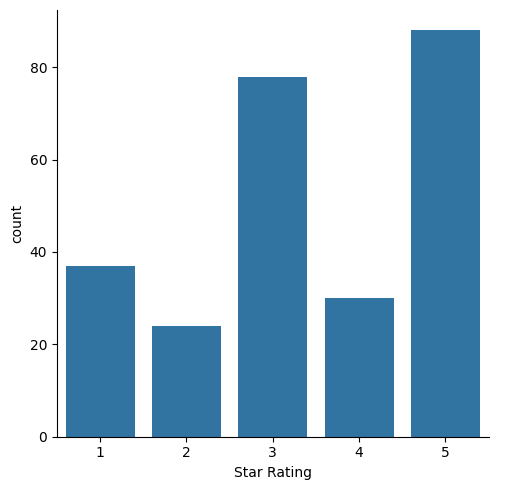

In [8]:
sns.catplot(x="Star Rating", data=df, kind="count")

## Preparamos el dataset
Divide en train/test y escala las features en el rango [0, 1].

In [9]:
from sklearn.model_selection import train_test_split

X = df[['wordcount', 'sentimentValue']]
y = df['Star Rating']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=29)

In [10]:
print(X_train.shape)
print(X_test.shape)
print(y_train.shape)
print(y_test.shape)

(205, 2)
(52, 2)
(205,)
(52,)


In [11]:
from sklearn.preprocessing import MinMaxScaler

# 1. Creamos el objeto scaler. Por defecto, transformará los datos al rango [0, 1]
scaler = MinMaxScaler()

# 2. 'fit_transform' hace dos cosas con X_train:
#    - fit: Calcula el valor mínimo y máximo de cada columna.
#    - transform: Aplica la fórmula (x - min) / (max - min) para escalar los datos.
X_train_scal = scaler.fit_transform(X_train)

# 3. Con X_test usamos SOLO 'transform'. 
#    Usamos los mismos mínimos y máximos calculados con X_train para evitar "fuga de datos".
X_test_scal = scaler.transform(X_test)

# 4. Verificación: El mínimo de X_train_scal siempre será 0.0
print(X_train_scal.min())
# 5. Verificación: El máximo de X_train_scal siempre será 1.0
print(X_train_scal.max())

# 6. En X_test, los valores podrían ser ligeramente menores a 0 o mayores a 1 
#    si X_test tiene valores fuera del rango encontrado originalmente en X_train.
print(X_test_scal.min())
print(X_test_scal.max())

0.0
1.0
0.0
1.36


## Creamos el Modelo
Entrena con un KNN y evalúa el error en train y en test

In [12]:
from sklearn.neighbors import KNeighborsClassifier

In [25]:
knn = KNeighborsClassifier(n_neighbors=5)

In [26]:
knn.fit(X_train_scal, y_train)

,"n_neighbors n_neighbors: int, default=5Number of neighbors to use by default for :meth:`kneighbors` queries.",5
,"weights weights: {'uniform', 'distance'}, callable or None, default='uniform'Weight function used in prediction. Possible values:- 'uniform' : uniform weights. All points in each neighborhood are weighted equally.- 'distance' : weight points by the inverse of their distance. in this case, closer neighbors of a query point will have a greater influence than neighbors which are further away.- [callable] : a user-defined function which accepts an array of distances, and returns an array of the same shape containing the weights.Refer to the example entitled:ref:`sphx_glr_auto_examples_neighbors_plot_classification.py`showing the impact of the `weights` parameter on the decisionboundary.",'uniform'
,"algorithm algorithm: {'auto', 'ball_tree', 'kd_tree', 'brute'}, default='auto'Algorithm used to compute the nearest neighbors:- 'ball_tree' will use :class:`BallTree`- 'kd_tree' will use :class:`KDTree`- 'brute' will use a brute-force search.- 'auto' will attempt to decide the most appropriate algorithm based on the values passed to :meth:`fit` method.Note: fitting on sparse input will override the setting ofthis parameter, using brute force.",'auto'
,"leaf_size leaf_size: int, default=30Leaf size passed to BallTree or KDTree. This can affect thespeed of the construction and query, as well as the memoryrequired to store the tree. The optimal value depends on thenature of the problem.",30
,"p p: float, default=2Power parameter for the Minkowski metric. When p = 1, this is equivalentto using manhattan_distance (l1), and euclidean_distance (l2) for p = 2.For arbitrary p, minkowski_distance (l_p) is used. This parameter is expectedto be positive.",2
,"metric metric: str or callable, default='minkowski'Metric to use for distance computation. Default is ""minkowski"", whichresults in the standard Euclidean distance when p = 2. See thedocumentation of `scipy.spatial.distance`_ andthe metrics listed in:class:`~sklearn.metrics.pairwise.distance_metrics` for valid metricvalues.If metric is ""precomputed"", X is assumed to be a distance matrix andmust be square during fit. X may be a :term:`sparse graph`, in whichcase only ""nonzero"" elements may be considered neighbors.If metric is a callable function, it takes two arrays representing 1Dvectors as inputs and must return one value indicating the distancebetween those vectors. This works for Scipy's metrics, but is lessefficient than passing the metric name as a string.",'minkowski'
,"metric_params metric_params: dict, default=NoneAdditional keyword arguments for the metric function.",None
,"n_jobs n_jobs: int, default=NoneThe number of parallel jobs to run for neighbors search.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details.Doesn't affect :meth:`fit` method.",None


## Evalúa tu modelo

In [27]:
from sklearn.metrics import confusion_matrix, multilabel_confusion_matrix, classification_report

In [28]:
y_pred = knn.predict(X_test_scal)
print("accuracy_score", accuracy_score(y_test, y_pred))
print("confusion_matrix\n", confusion_matrix(y_test, y_pred))
print("accuracy_score\n", multilabel_confusion_matrix(y_test, y_pred))

accuracy_score 0.8076923076923077
confusion_matrix
 [[ 4  0  3  0  0]
 [ 0  7  0  0  0]
 [ 0  0 15  1  1]
 [ 0  1  0  4  0]
 [ 0  0  2  2 12]]
accuracy_score
 [[[45  0]
  [ 3  4]]

 [[44  1]
  [ 0  7]]

 [[30  5]
  [ 2 15]]

 [[44  3]
  [ 1  4]]

 [[35  1]
  [ 4 12]]]


## ¿Cómo obtener el mejor valor de k? Crea y evalúa nuevos modelos
¿Qué valor de k maximiza el accuracy? Representa todas las iteraciones en un scatterplot -> k vs accuracy

In [31]:
from sklearn.model_selection import GridSearchCV

model = KNeighborsClassifier()

parameters = {"n_neighbors": range(1,30)}

gs_knn = GridSearchCV(model, parameters, cv=10, scoring="accuracy", n_jobs=-1)

gs_knn.fit(X_train_scal, y_train)

,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",KNeighborsClassifier()
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'n_neighbors': range(1, 30)}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",'accuracy'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide ` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",10
,"verbose verbose: intControls the verbosity: the higher, the more messages.- >1 : the computation time for each fold and parameter candidate is displayed;- >2 : the score is also displayed;- >3 : the fold and candidate parame

In [33]:
print(gs_knn.best_estimator_)
print(gs_knn.best_params_)
print(gs_knn.best_score_)

KNeighborsClassifier(n_neighbors=4)
{'n_neighbors': 4}
0.8885714285714286


In [37]:
# Cambiamos el rango para que salte de 2 en 2 (solo impares: 1, 3, 5, 7...)
parameters = {"n_neighbors": range(1, 31, 2)}

# Ejecutamos la búsqueda con validación cruzada
gs_knn = GridSearchCV(model, parameters, cv=10, scoring="accuracy", n_jobs=-1)
gs_knn.fit(X_train_scal, y_train)

# Vemos cuál es el nuevo ganador
print(f"Nuevo K ideal (impar): {gs_knn.best_params_}")
print(f"Nueva precisión en validación: {gs_knn.best_score_:.4f}")

# Evaluación final con el set de test
final_score = gs_knn.score(X_test_scal, y_test)
print(f"Nueva precisión final en TEST: {final_score:.4f}")

Nuevo K ideal (impar): {'n_neighbors': 3}
Nueva precisión en validación: 0.8788
Nueva precisión final en TEST: 0.7692


In [44]:
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
# Probamos K impares Y también dos tipos de pesos
parameters = {
    "n_neighbors": range(1, 31, 2),
    "weights": ["uniform", "distance"] # 'distance' da más peso a los vecinos más cercanos
}

gs_knn = GridSearchCV(model, parameters, cv=10, scoring="accuracy", n_jobs=-1)
gs_knn.fit(X_train_scal, y_train)

print(f"Mejores parámetros: {gs_knn.best_params_}")
print(f"Nueva precisión en TEST: {gs_knn.score(X_test_scal, y_test):.4f}")

Mejores parámetros: {'n_neighbors': 5, 'weights': 'distance'}
Nueva precisión en TEST: 0.7885


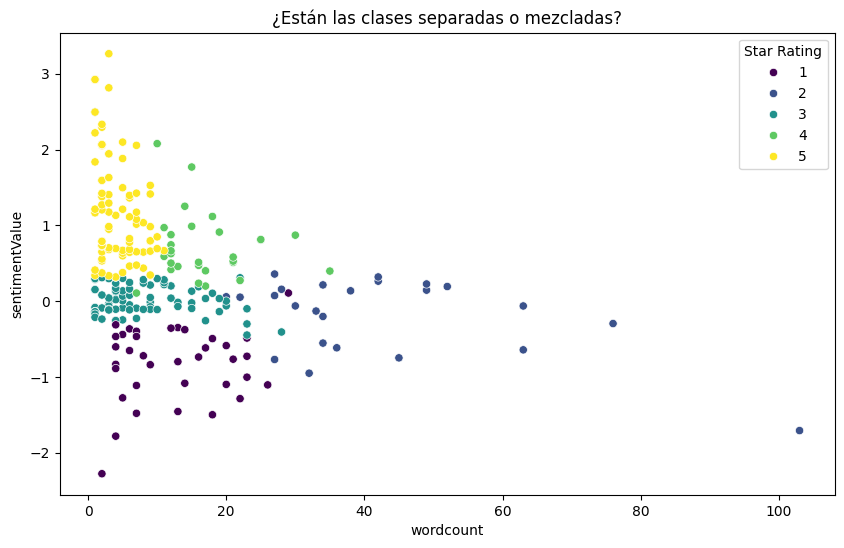

In [ ]:
# Esto mostrará cómo se mezclan las clases en el espacio # Tenemos solapamiento lo que hace mas dificil la separacion y que haya diferencia en train y test
plt.figure(figsize=(10,6))
sns.scatterplot(x='wordcount', y='sentimentValue', hue='Star Rating', data=df, palette='viridis')
plt.title('¿Están las clases separadas o mezcladas?')
plt.show()

In [47]:
# 1. Agrupamos las estrellas: 1-2 son 'Baja', 3 es 'Media', 4-5 son 'Alta'
# Usamos el objeto 'y' que ya tenías definido
y_agrupada = y.replace({1: 1, 2: 1, 3: 2, 4: 3, 5: 3})

# 2. Nueva división de datos
X_train, X_test, y_train_agr, y_test_agr = train_test_split(X, y_agrupada, test_size=0.2, random_state=42)

# 3. Escalado robusto
scaler = StandardScaler()
X_train_scal = scaler.fit_transform(X_train)
X_test_scal = scaler.transform(X_test)

# 4. Buscamos el mejor K para estas nuevas categorías
parameters = {
    "n_neighbors": range(1, 21, 2), 
    "weights": ["uniform", "distance"]
}

gs_knn_agr = GridSearchCV(KNeighborsClassifier(), parameters, cv=10, scoring="accuracy")
gs_knn_agr.fit(X_train_scal, y_train_agr)

# 5. Resultados finales
print(f"Mejores parámetros: {gs_knn_agr.best_params_}")
print(f"Nueva precisión en TEST: {gs_knn_agr.score(X_test_scal, y_test_agr):.4f}")

Mejores parámetros: {'n_neighbors': 11, 'weights': 'uniform'}
Nueva precisión en TEST: 0.9038


In [49]:
from sklearn.model_selection import cross_val_score
from sklearn.metrics import classification_report, confusion_matrix
# 1. Comprobamos la brecha Entrenamiento vs Test
train_acc = gs_knn_agr.best_score_
test_acc = gs_knn_agr.score(X_test_scal, y_test_agr)

print(f"Precisión media en Validación (Train): {train_acc:.4f}")
print(f"Precisión en Test: {test_acc:.4f}")
print(f"Diferencia (Brecha): {abs(train_acc - test_acc):.4f}")

# 2. Validación Cruzada Total (para asegurar que no fue suerte con el set de test)
# Usamos el mejor modelo encontrado: K=11, weights='uniform'
cv_scores = cross_val_score(gs_knn_agr.best_estimator_, X_train_scal, y_train_agr, cv=10)
print(f"\nEstabilidad del modelo (CV Mean): {cv_scores.mean():.4f} (+/- {cv_scores.std() * 2:.4f})")

# 3. Reporte detallado por cada una de las 3 nuevas clases
y_pred = gs_knn_agr.predict(X_test_scal)
print("\n--- REPORTE DE CLASIFICACIÓN AGRUPADO ---")
print(classification_report(y_test_agr, y_pred))

print("\n--- MATRIZ DE CONFUSIÓN ---")
print(confusion_matrix(y_test_agr, y_pred))

Precisión media en Validación (Train): 0.9029
Precisión en Test: 0.9038
Diferencia (Brecha): 0.0010

Estabilidad del modelo (CV Mean): 0.9029 (+/- 0.1213)

--- REPORTE DE CLASIFICACIÓN AGRUPADO ---
              precision    recall  f1-score   support

           1       0.79      0.92      0.85        12
           2       0.86      0.86      0.86        14
           3       1.00      0.92      0.96        26

    accuracy                           0.90        52
   macro avg       0.88      0.90      0.89        52
weighted avg       0.91      0.90      0.91        52


--- MATRIZ DE CONFUSIÓN ---
[[11  1  0]
 [ 2 12  0]
 [ 1  1 24]]


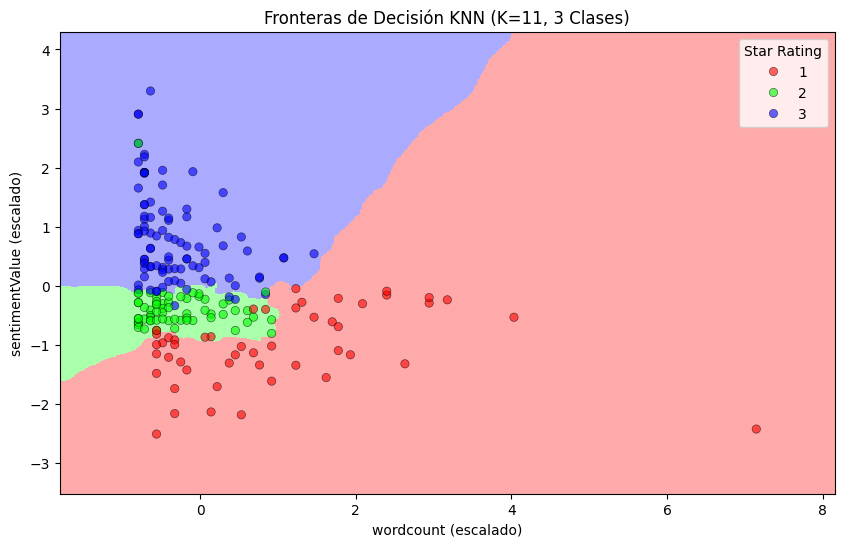

In [53]:
from matplotlib.colors import ListedColormap

# 1. Creamos una malla de puntos (grid) que cubra el rango de tus datos escalados
h = .02  # Tamaño del paso en la malla
x_min, x_max = X_train_scal[:, 0].min() - 1, X_train_scal[:, 0].max() + 1
y_min, y_max = X_train_scal[:, 1].min() - 1, X_train_scal[:, 1].max() + 1
xx, yy = np.meshgrid(np.arange(x_min, x_max, h), np.arange(y_min, y_max, h))

# 2. Predecimos la clase para cada punto de la malla
Z = gs_knn_agr.predict(np.c_[xx.ravel(), yy.ravel()])
Z = Z.reshape(xx.shape)

# 3. Definimos los colores (uno para cada una de tus 3 clases)
cmap_light = ListedColormap(['#FFAAAA', '#AAFFAA', '#AAAAFF']) # Colores de fondo
cmap_bold = ['#FF0000', '#00FF00', '#0000FF']                # Colores de los puntos

# 4. Dibujamos el mapa
plt.figure(figsize=(10, 6))
plt.pcolormesh(xx, yy, Z, cmap=cmap_light, shading='auto')

# 5. Dibujamos también los datos reales para ver cómo caen en las zonas
import seaborn as sns
sns.scatterplot(x=X_train_scal[:, 0], y=X_train_scal[:, 1], hue=y_train_agr,
                palette=cmap_bold, edgecolor="black", alpha=0.6)

plt.title("Fronteras de Decisión KNN (K=11, 3 Clases)")
plt.xlabel("wordcount (escalado)")
plt.ylabel("sentimentValue (escalado)")
plt.show()

## Predice con nuevos datos.
Ejemplo: supongamos que nos llega una review de 5 palabras y sentimiento 1

In [54]:
# 1. Creamos el nuevo dato con los nombres de columna correctos
# Review de 5 palabras y sentimiento 1.0
nuevo_dato_df = pd.DataFrame([[5, 1.0]], columns=['wordcount', 'sentimentValue'])

# 2. Escalamos usando el nuevo StandardScaler
nuevo_dato_scal = scaler.transform(nuevo_dato_df)

# 3. Predecimos con el modelo agrupado
prediccion = gs_knn_agr.predict(nuevo_dato_scal)

# Interpretación del resultado
categorias = {1: "Mala (1-2 estrellas)", 2: "Neutra (3 estrellas)", 3: "Buena (4-5 estrellas)"}
print(f"La categoría predicha es: {prediccion[0]} -> {categorias[prediccion[0]]}")

La categoría predicha es: 3 -> Buena (4-5 estrellas)
